# Worksheet 6 - Classical machine learning

In [26]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

## 1 - Data

**Open data, drop NaN, reset index:**

In [2]:
Sample_A = pd.read_csv('Exoplanet_Data.csv')
Sample_A = Sample_A.dropna()
Sample_A = Sample_A.reset_index(drop=True)

print('There are ', len(Sample_A), 'galaxies in this sample')
Sample_A

There are  1444 galaxies in this sample


,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_masse,pl_masseerr1,...,pl_denserr2,pl_denslim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,st_mass,st_masserr1,st_masserr2,st_masslim
0,0.01544,0.00009,-0.00009,0.0,2.080000,0.160000,-0.170000,0.0,7.81000,0.58000,...,-1.200,0.0,1958.0,15.0,-15.0,0.0,0.905,0.015,-0.015,0.0
1,0.06450,0.00130,-0.00130,0.0,4.070000,0.170000,-0.170000,0.0,17.00000,5.00000,...,-0.400,0.0,593.0,21.0,-21.0,0.0,0.500,0.030,-0.030,0.0
2,0.07000,0.00600,-0.00700,0.0,4.790000,0.290000,-0.290000,0.0,8.99000,2.61000,...,-0.160,0.0,554.8,31.6,-32.0,0.0,0.635,0.040,-0.070,0.0
3,0.11900,0.01100,-0.01100,0.0,2.790000,0.180000,-0.170000,0.0,14.46000,3.24000,...,-1.170,0.0,424.7,24.2,-24.5,0.0,0.635,0.040,-0.070,0.0
4,0.11010,0.00220,-0.00220,0.0,3.240000,0.160000,-0.160000,0.0,13.60000,11.40000,...,-1.900,0.0,454.0,16.0,-16.0,0.0,0.500,0.030,-0.030,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439,0.05080,0.00050,-0.00050,0.0,12.890350,1.345080,-1.345080,0.0,365.50450,25.42640,...,-0.300,0.0,1244.0,48.0,-48.0,0.0,1.000,0.030,-0.030,0.0
1440,0.05150,0.00050,-0.00050,0.0,12.780000,0.340000,-0.340000,0.0,378.20000,9.53000,...,-0.080,0.0,1230.0,20.0,-20.0,0.0,1.040,0.030,-0.030,0.0
1441,0.04421,0.00062,-0.00062,0.0,15.389957,0.291434,-0.291434,0.0,225.34147,10.80622,...,-0.027,0.0,1743.0,23.0,-23.0,0.0,1.405,0.059,-0.059,0.0
1442,0.06702,0.00109,-0.00109,0.0,2.060000,0.030000,-0.030000,0.0,4.52000,0.81000,...,-0.530,0.0,1147.0,12.0,-12.0,0.0,1.020,0.030,-0.030,0.0


**Feature space:**

In [3]:
def feature_space(df, columns):

    """
    Prepares feature space by applying logarithmic transformation and standardisation

    Parameters
    ----------
    df: input pandas data
    columns: list of columns used for the feature space

    Returns
    -------
    Preprocessed feature space as numpy array
    """

    
    fs = df[columns]
    fs = np.log10(fs)
    
    scaler = StandardScaler()
    X = scaler.fit_transform(fs)
    
    return X

In [4]:
X1 = feature_space(Sample_A, ['pl_masse', 'pl_rade', 'pl_dens', 'pl_orbsmax'])
X2 = feature_space(Sample_A, ['pl_masse', 'pl_rade', 'pl_eqt'])
X3 = feature_space(Sample_A, ['pl_orbsmax', 'pl_dens'])
X4 = feature_space(Sample_A, ['pl_masse', 'pl_rade'])
X5 = feature_space(Sample_A, ['pl_orbsmax', 'pl_rade'])
X6 = feature_space(Sample_A, ['pl_eqt', 'pl_rade'])

feature_spaces = {
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'X5': X5,
    'X6': X6
}

## 2 - Creating labels

**Calculate BIC to estimate optimal number of components for the Gaussian Mixture Model:**

In [5]:
bic_results = {}

for name, X in feature_spaces.items():
    bic = []

    for k in range(1, 10):

        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X)
        bic.append(gmm.bic(X))

    bic_results[name] = bic

In [6]:
print('Best BIC values for each feature space:\n')

for name, bic in bic_results.items():
    best_value = np.argmin(bic)

    best_k = best_value + 1
    best_bic = bic[best_value]

    print(
        f'{name}: '
        f'best number of components = {best_k}, '
        f'BIC = {best_bic:.2f}'
    )

Best BIC values for each feature space:

X1: best number of components = 7, BIC = 181.04
X2: best number of components = 7, BIC = 6582.84
X3: best number of components = 5, BIC = 7734.75
X4: best number of components = 5, BIC = 3871.11
X5: best number of components = 6, BIC = 6299.67
X6: best number of components = 4, BIC = 5736.46


**Gaussian Mixture Model:**

Calculate GMM for the different feature spaces, using the best number of components for each (using BIC estimation). Fit the model and use predict to get the labels and use PCA to get the two Principal Components for the 2D projection:

In [7]:
gmm_results = {}

for name, X in feature_spaces.items():
    best_k = np.argmin(bic_results[name]) + 1

    gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
    gmm.fit(X)

    labels = gmm.predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    gmm_results[name] = {
        'best_k': best_k,
        'labels': labels,
        'pca': X_pca,
        'gmm': gmm
    }

    fs = feature_spaces[name].copy()
    #fs['cluster'] = labels
    gmm_results[name]['features'] = fs

**Plotting:**

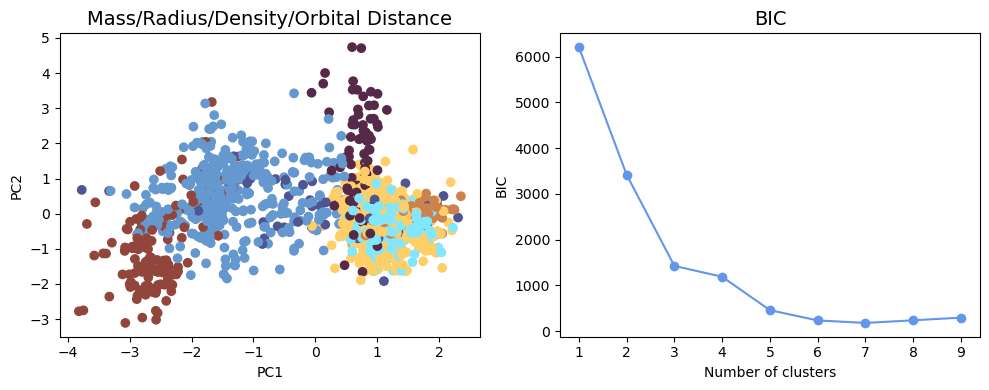

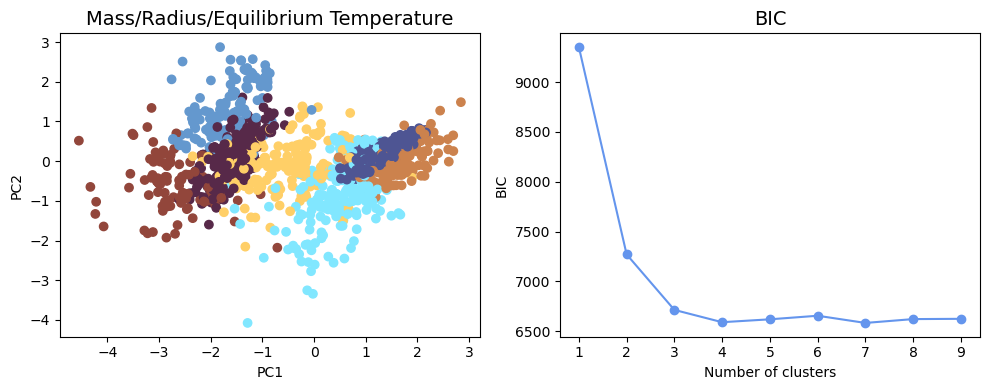

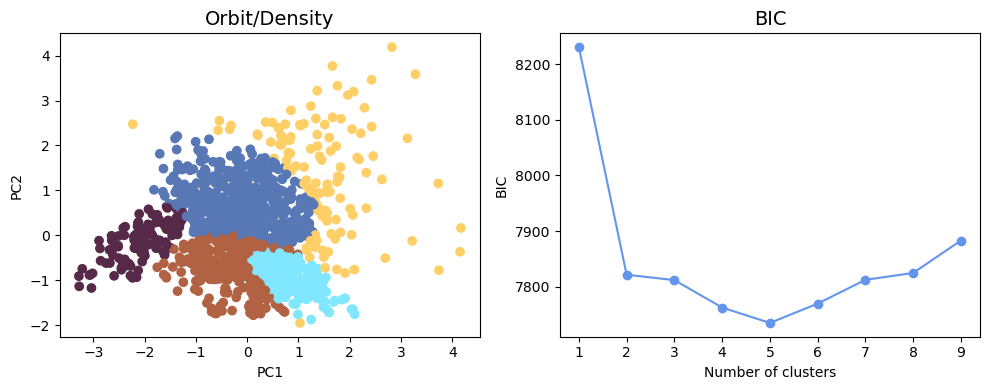

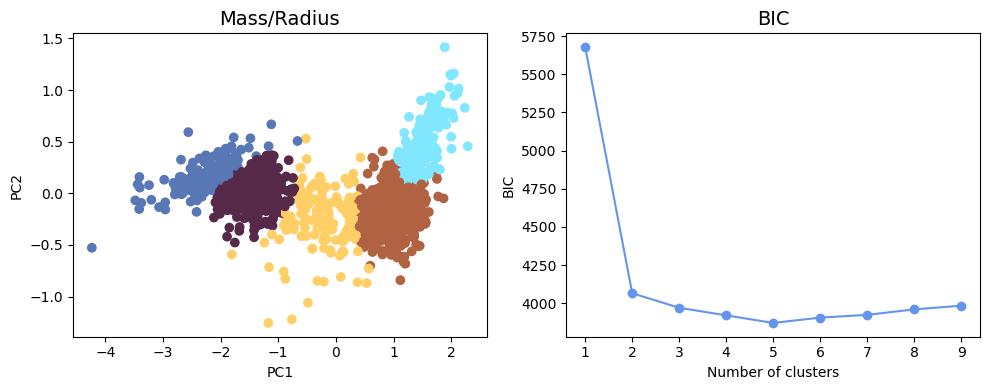

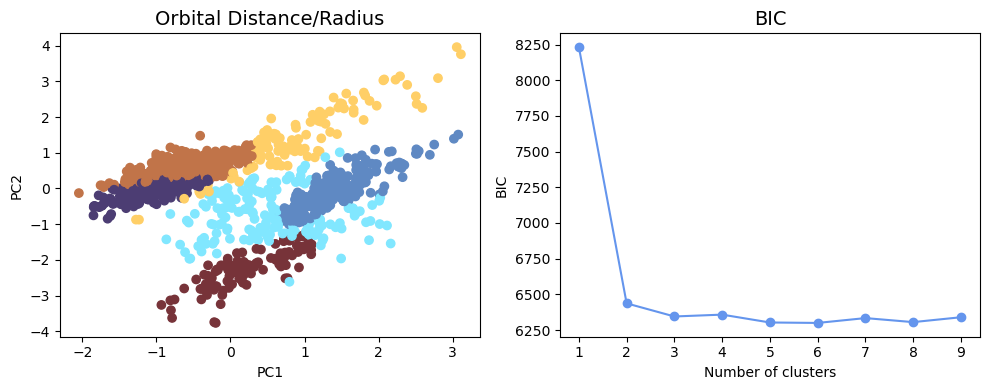

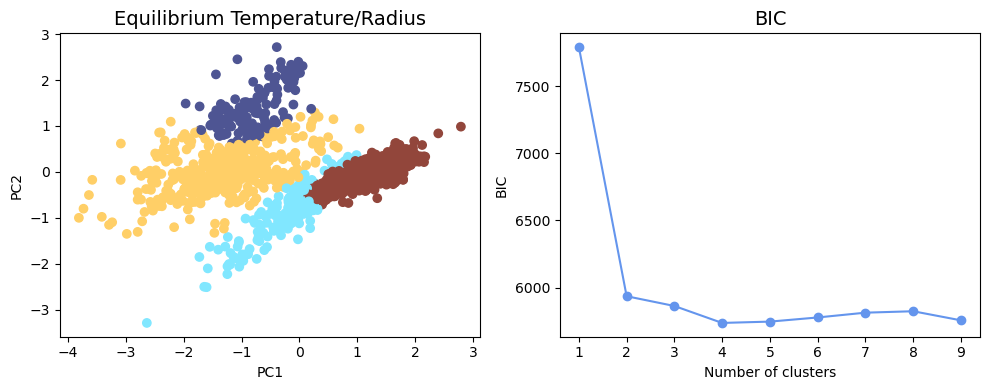

In [8]:

fs_properties = {
    'X1': 'Mass/Radius/Density/Orbital Distance',
    'X2': 'Mass/Radius/Equilibrium Temperature',
    'X3': 'Orbit/Density',
    'X4': 'Mass/Radius',
    'X5': 'Orbital Distance/Radius',
    'X6': 'Equilibrium Temperature/Radius'
}

for name in feature_spaces.keys():

    X_pca = gmm_results[name]['pca']
    labels = gmm_results[name]['labels']
    bic = bic_results[name] 

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='managua')
    axes[0].set_title(fs_properties[name], fontsize=14)
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')

   
    axes[1].plot(range(1, 10), bic, marker='o', color='cornflowerblue')
    axes[1].set_title('BIC', fontsize=14)
    axes[1].set_xlabel('Number of clusters')
    axes[1].set_ylabel('BIC')

    plt.tight_layout()
    plt.show()

**Split in train and test dataset (using feature space 4, because it yielded good results above):**

In [9]:
X4 = feature_spaces['X4']
y = gmm_results['X4']['labels']

X_train, X_test, y_train, y_test = train_test_split(X4, y, test_size=0.01, random_state=42)

## 3 - Classification of test data

**k-nearest neighbour algorithm:**

In [ ]:
k_values = range(1, 20)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f'k={k}, accuracy={acc:.3f}')

k=1, accuracy=1.000
k=2, accuracy=1.000
k=3, accuracy=1.000
k=4, accuracy=1.000
k=5, accuracy=1.000
k=6, accuracy=1.000
k=7, accuracy=1.000
k=8, accuracy=1.000
k=9, accuracy=1.000
k=10, accuracy=1.000
k=11, accuracy=1.000
k=12, accuracy=1.000
k=13, accuracy=1.000
k=14, accuracy=1.000
k=15, accuracy=1.000
k=16, accuracy=1.000
k=17, accuracy=1.000
k=18, accuracy=1.000
k=19, accuracy=1.000


In [22]:
best_k = k_values[np.argmax(accuracies)]
print("Best k:", best_k)

Best k: 1


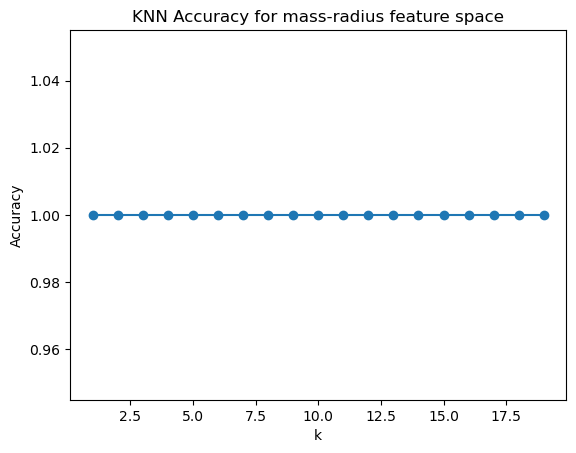

In [35]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for mass-radius feature space')
plt.show()

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

y_pred_knn = best_knn.predict(X_test)

print("Final KNN accuracy:", accuracy_score(y_test, y_pred_knn))

Final KNN accuracy: 1.0


**Solar system predictions:**

In [18]:
solar_system = np.array([
    [0.055, 0.383],   # Mercury
    [0.815, 0.949],   # Venus
    [1.0,   1.0],     # Earth
    [0.107, 0.532],   # Mars
    [317.8, 11.2],    # Jupiter
    [95.2,  9.45],    # Saturn
    [14.5,  4.01],    # Uranus
    [17.1,  3.88]     # Neptune
])

scaler = StandardScaler()
solar_fs = np.log10(solar_system)
X_solar = scaler.fit_transform(solar_fs)
solar_scaled = scaler.transform(solar_fs)

In [ ]:
solar_pred = best_knn.predict(solar_scaled)

names = ['Mercury','Venus','Earth','Mars',
         'Jupiter','Saturn','Uranus','Neptune']

for n, p in zip(names, solar_pred):
    print(n, '-> class', p)

Mercury -> class 2
Venus -> class 2
Earth -> class 2
Mars -> class 2
Jupiter -> class 1
Saturn -> class 1
Uranus -> class 1
Neptune -> class 1


**Support Vector Machine:**

In [ ]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print('SVM accuracy:', accuracy_score(y_test, y_pred_svm))

SVM accuracy: 1.0


In [30]:
y_pred_svm = svm.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print('SVM Accuracy:', svm_accuracy)

SVM Accuracy: 1.0


In [33]:
solar_svm_pred = svm.predict(solar_scaled)

In [ ]:
planet_names = [
    'Mercury', 'Venus', 'Earth', 'Mars',
    'Jupiter', 'Saturn', 'Uranus', 'Neptune'
]

for name, pred in zip(planet_names, solar_svm_pred):
    print(f"{name} -> class {pred}")

Mercury -> class 2
Venus -> class 2
Earth -> class 2
Mars -> class 2
Jupiter -> class 4
Saturn -> class 1
Uranus -> class 1
Neptune -> class 1
